Here is a nice tutorial that i found:

[nice tutorial](https://www.youtube.com/watch?v=il8dMDlXrIE)

For this we will be using MedMNIST, specifically PneunomiaMNIST.
- MedMNIST is a collection of a medical image dataset designed for machine learning research.
- Most of the images are 28x28 images, although there are some that are 28x28x28 (3D), we will not be using those.

In [91]:
import os

from skimage.io import imread
from skimage.transform import resize
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from medmnist import PneumoniaMNIST
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier as rfc

Now we move on to preparing the data in a way that scikit can read it.


we concatenate all the images to have a bigger dataset. X will be the images, and y will be the labels

the
X = X.reshape(X.shape[0], -1)

is to turn 2D images into 1D arrays, making it easier for the ml algo.

the
X = X / 255.0

is to make evry value betwween 1 and 0 (apparently that helps ml algos a lot)

We limited the dataset to 3000 images. Through over 90 different tests we came to the conlcusion that this number would give us the best accuracy while also maintaining a reasonable training time. Goin below and beyond 3000 would actually reduce the test average accuracy, likely due to increased noise.

In [92]:
train_dataset = PneumoniaMNIST(split='train', download=True)
val_dataset = PneumoniaMNIST(split='val')
test_dataset = PneumoniaMNIST(split='test')

X = np.concatenate([
    train_dataset.imgs,
    val_dataset.imgs,
    test_dataset.imgs
])

y = np.concatenate([
    train_dataset.labels,
    val_dataset.labels,
    test_dataset.labels
]).flatten() #transfirm it into a 1d array

indices = np.random.permutation(len(X)) #we shuffle the dataset to make sure the training and test sets are representative of the overall dataset, and not biased by the order of the data.
X = X[indices]
y = y[indices]
X = X[:3000]
y = y[:3000]

X = X.reshape(X.shape[0], -1)
X = X / 255.0

label_names = [test_dataset.info["label"][str(i)] for i in range(len(test_dataset.info["label"]))]
print("label names: ", label_names) #label names

unique, counts = np.unique(y, return_counts=True)
print("Labels:", unique)
print("Counts:", counts)
print("Percentage:", counts / len(y) * 100)

print("train dataset shape: ", train_dataset.imgs.shape)
print("validation dataset shape: ", val_dataset.imgs.shape)
print("test dataset shape: ", test_dataset.imgs.shape)





label names:  ['normal', 'pneumonia']
Labels: [0 1]
Counts: [ 841 2159]
Percentage: [28.03333333 71.96666667]
train dataset shape:  (4708, 28, 28)
validation dataset shape:  (524, 28, 28)
test dataset shape:  (624, 28, 28)


this were we train and test split

here we split all of our data in 2 different sets, 80/20, selected randomly

In [93]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # its a very big dataset, so i can afford to have a big test set, and it will make the training faster.
    stratify=y, # makes sure the same proportion of each class is in the training and test sets, which is important for imbalanced datasets.
    shuffle=True,
    random_state=42 # make sure the split is reproducible
)

here is were we actually do the training

each combination of C and Gamma we are training 25 image classifiers (5 * 5)

then we chosse the best of all thoes classifiers


But how does this work?

Support Vector Classifier (SVC)

Here we have 2 types of data points.

SVC is gonna try to:
- draw a line (boundary between the data points)
- choose boundary that leaves the most posssible margin

C and Gamma:
- Bigger the C, the more important it is that every point is classified correctly (also big C means big model difficult to train)
- higer the Gamma, the more influence every data point is going to have on how to draw the line. (essentially, the lower Gamma is, the smoother the boundary is going to be)

After testing both C and Gamma outcomes across more than 50 runs, we removed values that were never selected as optimal. This would narrow the search down from 25 to 15 different combinations and make training the ML 40% faster while also gaining decimals of accuracy due to narrowing both variable's values.

The final parameter grid is:
- C: [1, 5, 10, 15, 20]
- Gamma: [0.1, 0.07, 0.05]

In [94]:
classifier = SVC()

parameters = [{'gamma' : [0.1, 0.07, 0.05], 'C' : [1, 5, 10, 15, 20]}]

grid_search = GridSearchCV(classifier, parameters)

grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [1, 5, ...], 'gamma': [0.1, 0.07, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate paramet

To compare the SVC results, we will also implement a Random Forest Classifier.

How Random Forest works is that instead of drawing a hyperplane like SVC did, Random Forest builds hundreds of decision trees. These trees look at the images slightly differently from one another. After that, each tree votes on an answer (YES/NO), and the vote with a majority on it wins. (extremely hypercomplex super-technical overexplanation of how RFC works, not even harvard CS graduates understand it)(satire btw).

This makes it more robust than SVC. Trees will make mistakes 100%, but errors tend to cancel each other out when they are combined.

n_estimators and random_state:
- n_estimators is how many trees you'll want to build. In this case, the more trees the better, although accuracy change won't improve much when you already have a lot of trees.
- random_state is another thing that we can see throughout this notebook, especially the number 42. This just basically means to make the results reproducible.

Unlike SVC, RFC doesn't require GridSearchCV to find good parameters, therefore we can get really good results without an time consuming parameter search. This is why RFC is significantly faster to train than SVC. In our tests, RFC trained in 15 seconds compared to SVC's 40 seconds, making RFC around 63% faster than SVC.

Unfortunately, RFC is not better in this environment. RFC performs better in complex environments with several clusters, and we only have 2 in this example.

We can finally conclude that for this file, SVC will be better compared to RFC.

In [95]:
rf_classifier = rfc(n_estimators=500, random_state=42)
rf_classifier.fit(x_train, y_train)

y_pred_rf = rf_classifier.predict(x_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("{}% of samples were correctly classified by Random Forest.".format(accuracy_rf * 100))

92.83333333333333% of samples were correctly classified by Random Forest.


We select the best estimator from GidSearch and run it on the test set. The best C and Gamma vary slightly between runs due to the shuffling, and accuracy stays on an average of 95.727%, with bigger extreme points variation (logical since we process more images).

Highest result we got was a 98.2%, and lowest result we got was a 93.95%. But the complete average was (as I mentioned before) 95.727%, increasing the average by ~0.7% in comparison of our last version.

In [96]:

best_estimator = grid_search.best_estimator_


y_pred = best_estimator.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)

print("{}% of samples were correctly classified.".format(accuracy * 100))

95.16666666666667% of samples were correctly classified.


Here is a matplotlib graph displaying some pictures.

we  do this by selecting 5 random samples, of images, showing the image, the true label, and the predicted label.

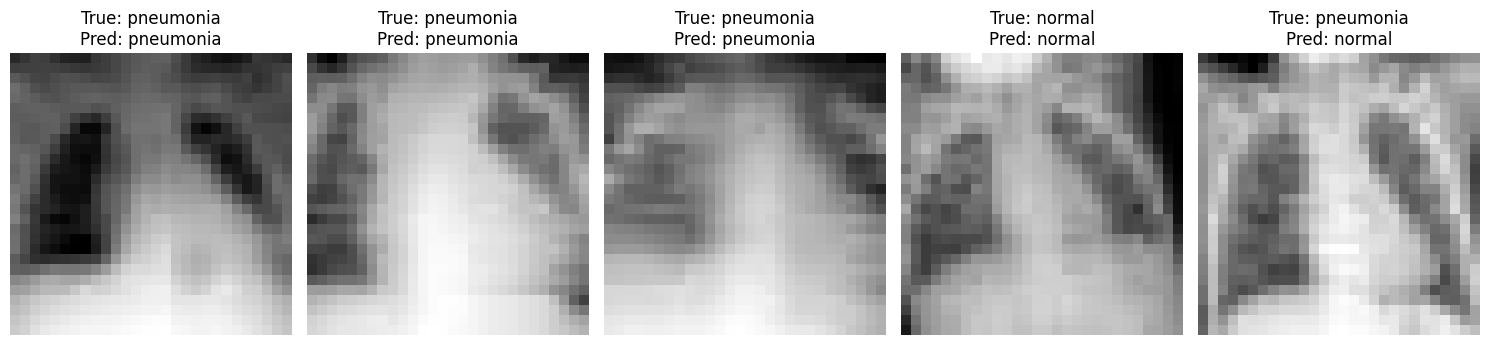

In [97]:

num_examples = 5
random_indices = np.random.choice(len(x_test), num_examples, replace=False)
plt.figure(figsize=(15, 5))
for i, idx in enumerate(random_indices):
    img = x_test[idx] #we will figure out the side by doing square root of size of the array
    shape = int(np.sqrt(img.shape[0]))
    img = img.reshape(shape, shape) # reshape the image back to its original shape (square root)
    true_label = label_names[y_test[idx]]
    predicted_label = label_names[y_pred[idx]]

    plt.subplot(1, num_examples, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f'True: {true_label}\nPred: {predicted_label}')
    plt.axis('off')
plt.tight_layout()
plt.show()


